In [42]:
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import numpy as np

In [43]:
sheet_id = "1VurJODWndk26VfyNd6IDgXsvX7uR1A_IxhTA4xcGRco"
sheet_gid = "0"
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={sheet_gid}"
full_df = pd.read_csv(url)

In [44]:
df = full_df.copy()
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
                           
now = datetime.now()
start_of_day = datetime(now.year, now.month, now.day)
start_of_month = datetime(now.year, now.month, 1)
start_of_week = now - timedelta(days=now.weekday())
current_quarter = (now.month - 1) // 3 + 1
start_of_quarter = datetime(now.year, 3 * (current_quarter - 1) + 1, 1)

df = df[df['Date'] < start_of_day]

df['Weight'] = df['Weight'].astype(str).str.replace(',', '.').str.strip()
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')
df['Weight'] = df['Weight'].interpolate(method='linear')

df.tail()

,Date,Weight
1346,2025-08-12,72.1
1347,2025-08-13,72.1
1348,2025-08-14,72.1
1349,2025-08-15,72.1
1350,2025-08-16,71.6


In [45]:
quarterly_df = df[df['Date'] < start_of_quarter].copy()
quarterly_df = quarterly_df.resample('QE', on='Date').mean().reset_index()

quarterly_df.tail()

,Date,Weight
10,2024-06-30,72.447253
11,2024-09-30,72.650543
12,2024-12-31,73.006522
13,2025-03-31,73.443333
14,2025-06-30,73.679121


In [46]:
monthly_df = df[df['Date'] < start_of_month].copy()
monthly_df = monthly_df.resample('ME', on='Date').mean().reset_index()

monthly_df.tail(5)

,Date,Weight
39,2025-03-31,73.561290
40,2025-04-30,73.563333
41,2025-05-31,73.809677
42,2025-06-30,73.660000
43,2025-07-31,73.290323


In [47]:
weekly_df = df[df['Date'] < start_of_week].copy()
weekly_df = weekly_df.resample('W-MON', on='Date').mean().reset_index()

weekly_df.tail()

,Date,Weight
188,2025-07-14,73.885714
189,2025-07-21,73.457143
190,2025-07-28,72.657143
191,2025-08-04,72.271429
192,2025-08-11,71.957143


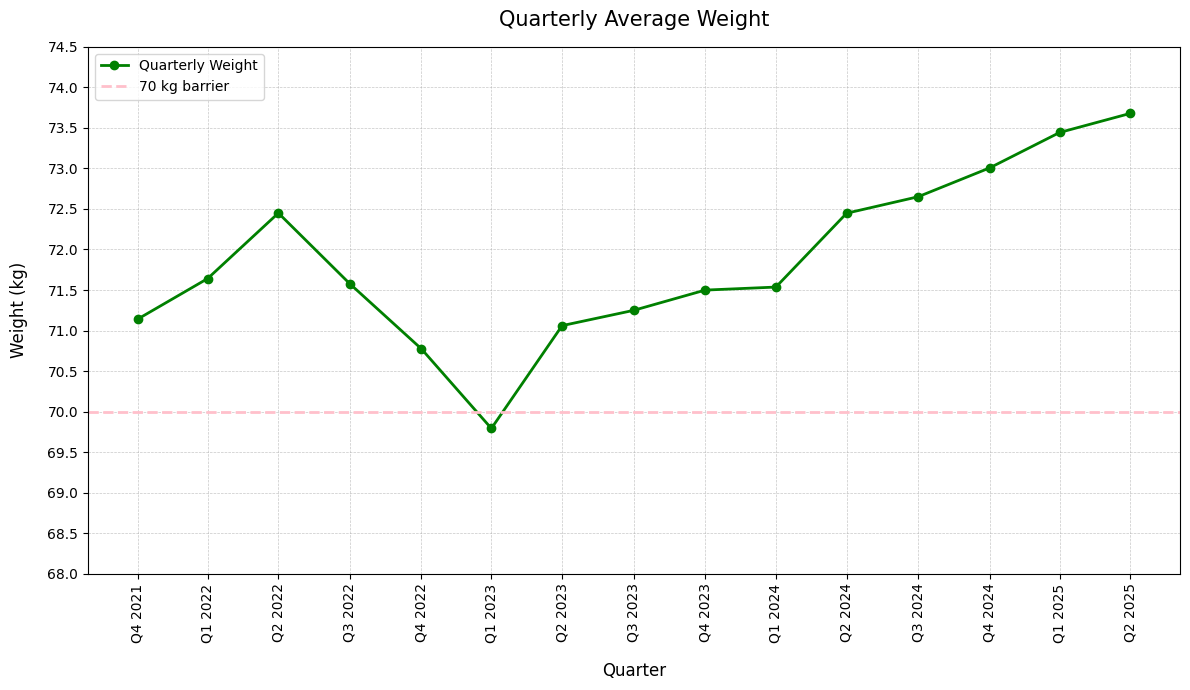

In [48]:
dates = quarterly_df['Date']
weights = quarterly_df['Weight']

plt.figure(figsize=(12, 7))
plt.plot(dates, weights, marker='o', linestyle='-', color='green', linewidth=2, label='Quarterly Weight')

plt.title('Quarterly Average Weight', pad=15, fontsize=15)
plt.xlabel('Quarter', fontsize=12, labelpad=14)
plt.ylabel('Weight (kg)', fontsize=12, labelpad=14)

# Etykiety osi X: wszystkie kwartały, obrócone
plt.xticks(ticks=dates, labels=[f"Q{((d.month - 1) // 3) + 1} {d.year}" for d in dates], rotation=90)

# Oś Y: kroki co 0.5 kg
min_weight = weights.min()
max_weight = weights.max()
plt.yticks(np.arange(np.floor(min_weight) - 1, np.ceil(max_weight) + 1, 0.5))

# Pogrubiona linia 70 kg
plt.axhline(y=70, color='pink', linestyle='--', linewidth=2, label='70 kg barrier')

# Subtelna siatka
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

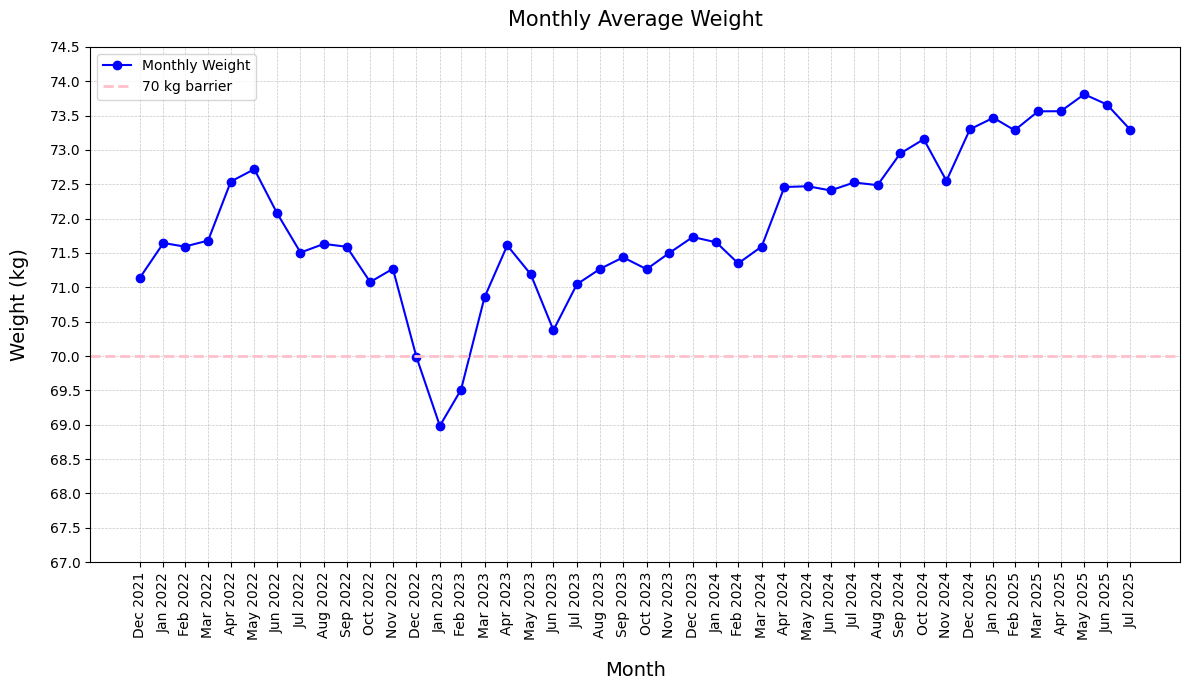

In [49]:
# Extract data
dates = monthly_df['Date']
weights = monthly_df['Weight']

# Create the plot
plt.figure(figsize=(12, 7))
plt.plot(dates, weights, marker='o', linestyle='-', color='blue', label='Monthly Weight')

# Set title and labels
plt.title('Monthly Average Weight', pad=15, fontsize=15)
plt.xlabel('Month', labelpad=15, fontsize=14)
plt.ylabel('Weight (kg)', labelpad=15, fontsize=14)

# Rotate x-axis labels
plt.xticks(ticks=dates, labels=[d.strftime('%b %Y') for d in dates], rotation=90)

# Set y-axis ticks in 0.5 kg steps
min_weight = weights.min()
max_weight = weights.max()
plt.yticks(np.arange(np.floor(min_weight) - 1, np.ceil(max_weight) + 1, 0.5))

# Add horizontal line at 70 kg
plt.axhline(y=70, color='pink', linestyle='--', linewidth=2, label='70 kg barrier')

# Grid and legend
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

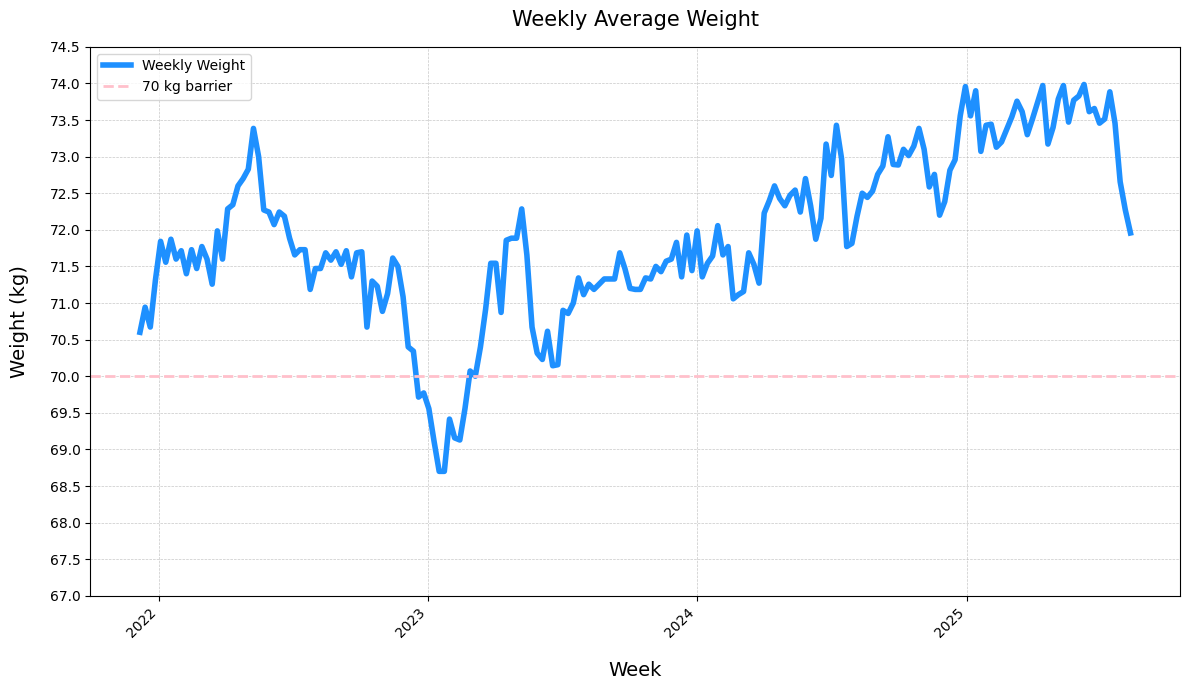

In [50]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# Extract data
dates = weekly_df['Date']
weights = weekly_df['Weight']

# Create the plot
plt.figure(figsize=(12, 7))

# Rysowanie linii BEZ markerów
plt.plot(dates, weights, linewidth=4, linestyle='-', color='dodgerblue', label='Weekly Weight')

# --- Ustawienia osi X, aby zmniejszyć gęstość dat ---
ax = plt.gca() # Pobierz bieżący obiekt Axes

# Ustawienie głównego lokalizatora co drugi tydzień
ax.xaxis.set_major_locator(mdates.YearLocator(1))

# Ustawienie formatera dat na format 'Miesiąc Rok'
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Upewnienie się, że etykiety są pochylone, aby były czytelne
plt.xticks(rotation=45, ha='right')
# --- Koniec ustawień osi X ---


# Set title and labels
plt.title('Weekly Average Weight', pad=15, fontsize=15)
plt.xlabel('Week', labelpad=15, fontsize=14)
plt.ylabel('Weight (kg)', labelpad=15, fontsize=14)

# Set y-axis ticks in 0.5 kg steps
min_weight = weights.min()
max_weight = weights.max()
plt.yticks(np.arange(np.floor(min_weight) - 1, np.ceil(max_weight) + 1, 0.5))

# Add horizontal line at 70 kg
plt.axhline(y=70, color='pink', linestyle='--', linewidth=2, label='70 kg barrier')

# Grid and legend
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()